In [ ]:
import pandas as pd
from random import choice

def estudiante_que_va_a_participar(ruta_archivo):
    try:
        # skiprows=2 hace que la lectura comience en la fila 3 del Excel
        # La fila 3 pasará a ser el encabezado (donde debe estar 'NOMBRES Y APELLIDOS')
        df = pd.read_excel(ruta_archivo, sheet_name=0, skiprows=2)
    except Exception as e:
        return f"Error al abrir el archivo: {e}"

    # Verificamos que la columna exista después del salto de filas
    if 'NOMBRES Y APELLIDOS' not in df.columns:
        return "Error: No se encontró la columna 'NOMBRES Y APELLIDOS' a partir de la fila 3."

    lista_estudiantes = df['NOMBRES Y APELLIDOS'].dropna().tolist()

    if lista_estudiantes:
        estudiante = choice(lista_estudiantes)
        print(f"El estudiante seleccionado es: {estudiante}")
        return estudiante
    else:
        print('Todos los estudiantes han participado o la lista está vacía.')
        return None
    
# Ruta del archivo
ruta = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia_notas_quices.xlsx"
estudiante_que_va_a_participar(ruta)

# Tema 6 Problema 1 

<img src = 'tema_6_problema_1.jpeg' width = 400>


## **1. Interpretación del problema**

- Pisos 1, 2, 3: tiempos 1 h, 2 h, 3 h respectivamente.
- Del piso 4 en adelante:  
  $$
  t_n = \text{promedio de tiempos de pisos 1, 2, ..., n-1}
  $$
- Queremos $t_{17}$.

---



## **2. Cálculo manual hasta ver patrón**

$$
t_1 = 1
$$
$$
t_2 = 2
$$
$$
t_3 = 3
$$
$$
t_4 = \frac{1+2+3}{3} = \frac{6}{3} = 2
$$
$$
t_5 = \frac{1+2+3+2}{4} = \frac{8}{4} = 2
$$
$$
t_6 = \frac{1+2+3+2+2}{5} = \frac{10}{5} = 2
$$



Vemos que desde $t_4$ en adelante, todos los tiempos son 2 h.  
Comprobemos $t_7$: suma hasta 6: $1+2+3+2+2+2 = 12$, promedio 12/6 = 2.  

Sí, se estabiliza en 2.



Entonces $t_{17} = 2$ horas.

**Respuesta: (b) 2 horas**

Conclusión, si a una colección de números le agregas su promedio, el nuevo promedio es igual al anterior. 


## **3. Tabla con pandas (primeros pisos)**


In [37]:
import pandas as pd

datos = []
tiempos = [1, 2, 3]  # primeros 3 pisos

for n in range(1, 19): # n es el número del piso 
    if n <= 3:
        t = n
    else:
        t = int(sum(tiempos[0:n-1]) / (n-1))
        tiempos.append(t)
    datos.append([n, t])

df = pd.DataFrame(datos, columns=['Piso', 'Tiempo (h)'])
df


,Piso,Tiempo (h)
0,1,1
1,2,2
2,3,3
3,4,2
4,5,2
5,6,2
6,7,2
7,8,2
8,9,2
9,10,2


## **4. Gráfico con matplotlib**

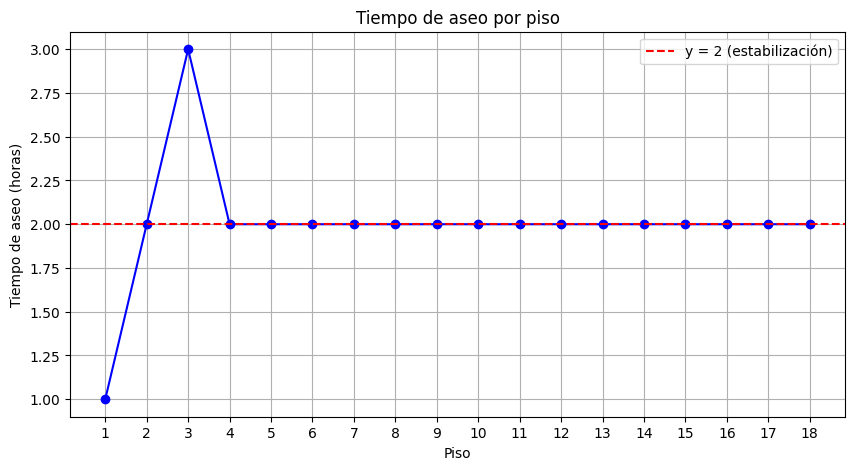

In [39]:
import matplotlib.pyplot as plt

pisos = df['Piso']
tiempos = df['Tiempo (h)']

plt.figure(figsize=(10,5))
plt.plot(pisos, tiempos, marker='o', linestyle='-', color='b')
plt.axhline(y=2, color='r', linestyle='--', label='y = 2 (estabilización)')
plt.xlabel('Piso')
plt.ylabel('Tiempo de aseo (horas)')
plt.title('Tiempo de aseo por piso')
plt.xticks(range(1,19))
plt.grid(True)
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\piso_vs_tiempo.png")
plt.show()


## **5. Problemas similares resueltos**

**Problema 1:**  
Para los pisos 1,2,3: 10, 20, 30 min. Del 4 en adelante: promedio de anteriores. Hallar tiempo piso 10.  
**Solución:**  
$t4 = (10+20+30)/3 = 20;$  
$t5 = (10+20+30+20)/4 = 80/4 = 20;$ se estabiliza en 20.  
$t10 = 20 min.$



**Problema 2:**  
Piso 1: 5 min, piso 2: 7 min, piso 3: 9 min. Del 4 en adelante: promedio anteriores. Hallar piso 8.  
**Solución:**  
t4 = (5+7+9)/3 = 21/3 = 7;  
t5 = (5+7+9+7)/4 = 28/4 = 7; estabilizado.  
t8 = 7 min.

---



**Problema 3:**  
Piso 1: 2 h, piso 2: 4 h, piso 3: 6 h. Del 4 en adelante: promedio anteriores. Hallar piso 12.  
**Solución:**  
t4 = (2+4+6)/3 = 12/3 = 4;  
t5 = (2+4+6+4)/4 = 16/4 = 4; estabilizado.  
t12 = 4 h.

---



**Problema 4:**  
Piso 1: 1 h, piso 2: 1 h, piso 3: 4 h. Del 4 en adelante: promedio anteriores. Hallar piso 9.  
**Solución:**  
t4 = (1+1+4)/3 = 6/3 = 2;  
t5 = (1+1+4+2)/4 = 8/4 = 2;  
t6 = (1+1+4+2+2)/5 = 10/5 = 2; estabilizado.  
t9 = 2 h.

---



**Problema 5:**  
Piso 1: 3 h, piso 2: 5 h, piso 3: 7 h. Del 4 en adelante: promedio anteriores. Hallar piso 20.  
**Solución:**  
t4 = (3+5+7)/3 = 15/3 = 5;  
t5 = (3+5+7+5)/4 = 20/4 = 5; estabilizado.  
t20 = 5 h.

# Pregunta 2 del Tema 6: Compensaciones aditivas y multiplicativas. 


# Clase 6

# Compensaciones aditivas y multiplicativas

Duración: **3 horas**

Este tema es **muy típico en pruebas de razonamiento cuantitativo** como las del examen de admisión de la Universidad de Antioquia porque evalúa **equilibrio de cantidades, ajustes y conservación de relaciones**.

---



# Objetivos de la clase

Al finalizar la clase el estudiante podrá:

* resolver problemas de **compensación aditiva**
* resolver problemas de **compensación multiplicativa**
* interpretar **equilibrios en gráficos**
* verificar soluciones con **Python**
* resolver preguntas **en menos de 2 minutos**

---



# Concepto 1

# Compensación aditiva

Una **compensación aditiva** ocurre cuando un aumento en una cantidad debe compensarse con una **disminución equivalente** en otra para mantener un equilibrio.

Ejemplo:

Si un promedio debe mantenerse constante, entonces

$$
\text{suma total} = \text{constante}
$$

---



# Concepto 2

# Compensación multiplicativa

Ocurre cuando el **producto entre variables debe permanecer constante**.

Ejemplo típico: trabajo, velocidad-tiempo, precio-cantidad.

$$
x \times y = k
$$

---



# PARTE I

# 13 problemas tipo prueba diagnóstica

---

# Problema 1

El promedio de **5 números** es $20$.

Si uno de los números aumenta en **5 unidades**, ¿qué debe ocurrir con otro número para que el promedio no cambie?

A) disminuir 2
B) disminuir 3
C) disminuir 5
D) disminuir 10

---



## Estrategia

Suma total original

$$
5 \times 20
$$

---

$$
100
$$

Si un número aumenta 5, la suma sería

$$
105
$$

Para mantener el promedio:

otro número debe disminuir **5**.

---

* **Respuesta: C**

---



## Python

```python
suma=5*20
suma_nueva=suma+5
suma_nueva-5
```

---



# Problema 2

Un estudiante tiene promedio $4.0$ en **4 notas**.

¿Cuánto debe obtener en la quinta nota para mantener el promedio?

A) 3
B) 4
C) 5
D) 6

---



## Estrategia

Suma actual

$$
4\times4=16
$$

Para mantener promedio:

$$
5\times4=20
$$

Nota necesaria

$$
20-16
$$

---



$$
4
$$

---

* **Respuesta B**

---



# Problema 3

Un trabajador realiza un trabajo en **6 días**.

Si ahora trabaja **el doble de rápido**, ¿cuánto tarda?

A) 2
B) 3
C) 4
D) 6

---

## Compensación multiplicativa

$$
\text{velocidad} \times \text{tiempo}
$$

---

Velocidad ×2

Tiempo ÷2

---

$$
3
$$

---

✅ **Respuesta B**

---

# Problema 4

Una máquina produce **200 piezas en 4 horas**.

¿Cuántas producirá en **6 horas**?

A) 250
B) 275
C) 300
D) 350

---

## Estrategia

Producción por hora

$$
200/4
$$

---

$$
50
$$

---

$$
50\times6
$$

---

$$
300
$$

---



* **Respuesta C**

---



# Problema 5 (con gráfico)

Producción de una fábrica.

```python


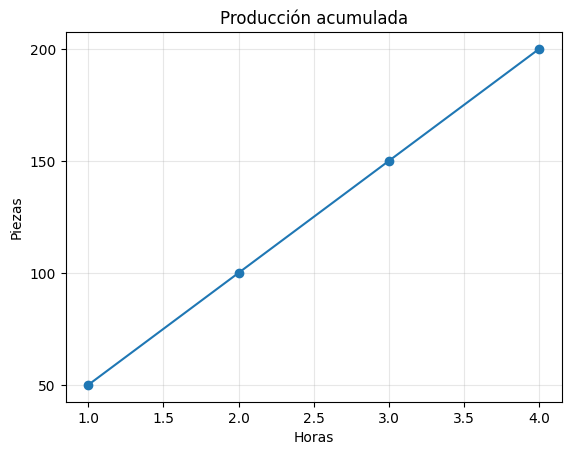

In [43]:
import numpy as np 
import matplotlib.pyplot as plt

horas=[1,2,3,4]
produccion=[50,100,150,200]

plt.plot(horas,produccion,marker="o")
plt.title("Producción acumulada")
plt.xlabel("Horas")
plt.ylabel("Piezas")
plt.grid(alpha = 0.3)
plt.yticks(np.arange(50, 250, 50))
plt.savefig(r"C:\Users\marco\Downloads\produccion_acumulada.png")
plt.show()



## Pregunta

Si la relación se mantiene, ¿cuántas piezas se producen en **5 horas**?

---

$$
50\times5
$$

---

$$
250
$$

---



# Problema 6

Si el precio de un producto aumenta **10%**, ¿cuánto debe disminuir la cantidad vendida para mantener el ingreso constante?

Ingreso

$$
P \times Q
$$

---

Aproximadamente

$$
10%
$$

---

# Problema 7

Promedio de 4 números es $10$.

Si uno aumenta en **4**, otro debe disminuir:

---

$$
4
$$

---

# Problema 8

Un auto recorre **120 km en 2 horas**.

A la misma velocidad en **3 horas** recorrerá

---

$$
180
$$

---

# Problema 9

Si el número de trabajadores se **duplica**, el tiempo necesario se:

---

divide entre

$$
2
$$

---

# Problema 10

Un tanque se llena en **10 horas**.

Con dos llaves iguales:

---

$$
5
$$

---

# Problema 11

Promedio de tres números es $15$.

Suma total

---

$$
45
$$

---

# Problema 12

Si el precio se duplica y la cantidad se reduce a la mitad, el ingreso:

---

permanece

---

**igual**

---

# Problema 13

Velocidad se triplica.

Tiempo necesario

---

$$
1/3
$$

---



# PARTE II

# 13 problemas similares (tipo examen)

---

# Problema 14

Promedio de **6 números** es $12$.

Suma total.

---

$$
72
$$

---



# Problema 15

Si un número aumenta **8**, otro debe disminuir:

---

$$
8
$$

---

# Problema 16

Velocidad ×2 → tiempo

---

$$
/2
$$

---

# Problema 17

Precio ×3 → cantidad

---

$$
/3
$$

---

# Problema 18

Promedio de **5 números = 30**

Suma

---

$$
150
$$

---

# Problema 19

Trabajo de 8 días con doble eficiencia.

---

$$
4
$$

---

# Problema 20

Producción por hora **60**

En **7 horas**

---

$$
420
$$

---



# Problema 21

Promedio de **4 números = 18**

Suma

---

$$
72
$$

---

# Problema 22

Precio ×1.2

Cantidad para ingreso constante

---

$$
\approx /1.2
$$

---

# Problema 23

Si trabajadores ×3 → tiempo

---

$$
/3
$$

---

# Problema 24

Promedio constante → compensación

---

**aditiva**

---

# Problema 25

Trabajo duplicado con misma velocidad → tiempo

---

×2

---



# Problema 26

Velocidad ×4 → tiempo

---

$$
/4
$$

---



# Visualización con matplotlib

# Compensación multiplicativa



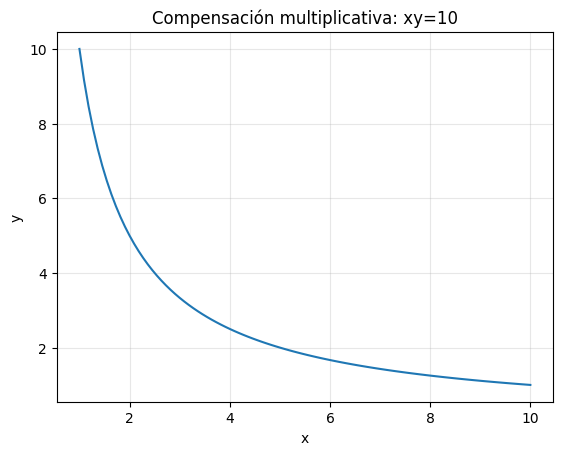

In [44]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(1,10,100)
y=10/x

plt.plot(x,y)
plt.title("Compensación multiplicativa: xy=10")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.5)
plt.grid(alpha = 0.3)
plt.savefig(r"C:\Users\marco\Downloads\compensacion_multiplicativa.png")
plt.show()



# Visualización de compensación aditiva



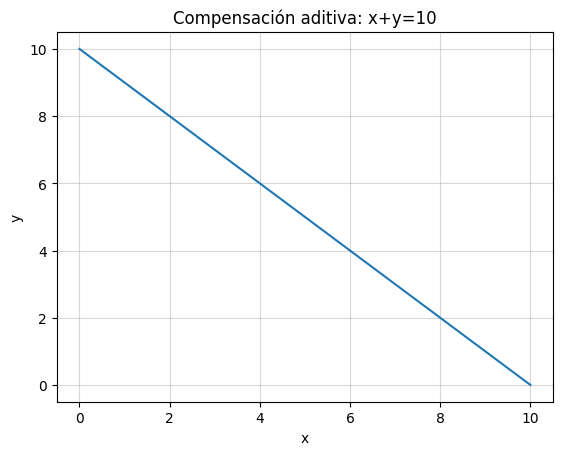

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(0,10,100)
y=10-x

plt.plot(x,y)
plt.title("Compensación aditiva: x+y=10")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.5)
plt.savefig(r"C:\Users\marco\Downloads\compensacion_aditiva.png")
plt.show()



# Estrategia para el examen

Cuando aparezcan estos problemas:

1. identificar si el **equilibrio es suma o producto**

* promedio → **compensación aditiva**
* trabajo / velocidad / precio-cantidad → **multiplicativa**

2. usar relaciones rápidas:

$$
x+y=k
$$

o

$$
xy=k
$$

---
